# Unlimited Sampling Beyond Modulo

## Introduction and Motivation

Analog-to-digital converters (ADCs) have a finite dynamic range $[-\lambda, \lambda]$. When a signal exceeds this limit, generally, the converter clips the signal, throwing away information irreversibly.

This notebook follows the implementation from the paper **Unlimited Sampling Beyond Modulo (Azar et al., 2025)** which proposes the algorithm $B^2R^2$ as a framework to recover bandlimited signals by exploiting signal properties in the time and fourier domain.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import pickle
import itertools

In [2]:
def paper_sinc(x):
    """Unnormalised sinc: sin(x)/x"""
    return np.sinc(x / np.pi)

A small note on the sinc function. The paper defines sinc as $\sin(\pi x)/(\pi x)$ (the normalised sinc). Using that convention here breaks the pipeline: real signal energy leaks into the band-gap $\rho$ that the algorithm assumes is empty. We use the unnormalised sinc $\sin(x)/x$ instead, which keeps the band edge at $\omega_m$ and consistent with the rest of the pipeline

## Generating the Test Signals

Two families of test signals are used in this experiment.

1. Single sinc

$$ f(nT_s) \;=\; \mathrm{sinc}\!\bigl(\omega_m \, nT_s\bigr) $$

2. Sum of sincs

$$ f(nT_s) \;=\; \sum_{k=-10}^{9} c_k \,\mathrm{sinc}\!\bigl(\omega_m T_s (n - 5k)\bigr), \qquad c_k \sim \mathcal{U}[-1, 1] $$

Normalised so that $\|f\|_\infty = 1$.

In [3]:
def make_test_signal(L, omega_m, OF, seed, type='single-sinc'):
    """Build the bandlimited test signals."""

    Ts = np.pi / (OF * omega_m)
    
    if type == 'sum-of-sincs':

        rng = np.random.default_rng(seed)
        k_values = list(range(-10, 10))
        coefficients = rng.uniform(-1.0, 1.0, size=20)

        t = np.arange(-L // 2, L // 2) * Ts

        f = []
        for ti in t:
            total = 0.0
            for k, c_k in zip(k_values, coefficients):
                centre   = 5 * k * Ts
                x = omega_m * (ti - centre)
                total   += c_k * paper_sinc(x)
            f.append(total)

        f = np.array(f)
        f = f / np.max(np.abs(f))

        return f, t
    
    if type == 'single-sinc':
        
        t = np.arange(-L // 2, L // 2) * Ts
        f = paper_sinc(omega_m * t)
        
        return f, t

In [4]:
# Test signal configuration

# Signal length in samples
L = 1024
# Signal bandwidth in rad/s
omega_m = 1.0
# Oversampling factor relative to Nyquist 
# (e.g. for OF=2; 2 x Nyquist rate; 4 x omega_m)
OF = 8
# Dynamic range
lam = 0.25
# Seed
seed = 0

### Derived quantities

# Time step
Ts = np.pi / (OF * omega_m)
# Sampling angular frequency
omega_s = 2 * np.pi / Ts


# Generating the signals

f, t = make_test_signal(L, omega_m, OF, seed, 'sum-of-sincs')
f_single_sinc, t_single_sinc = make_test_signal(L, omega_m, OF, seed, 'single-sinc')

Visualising test signals:

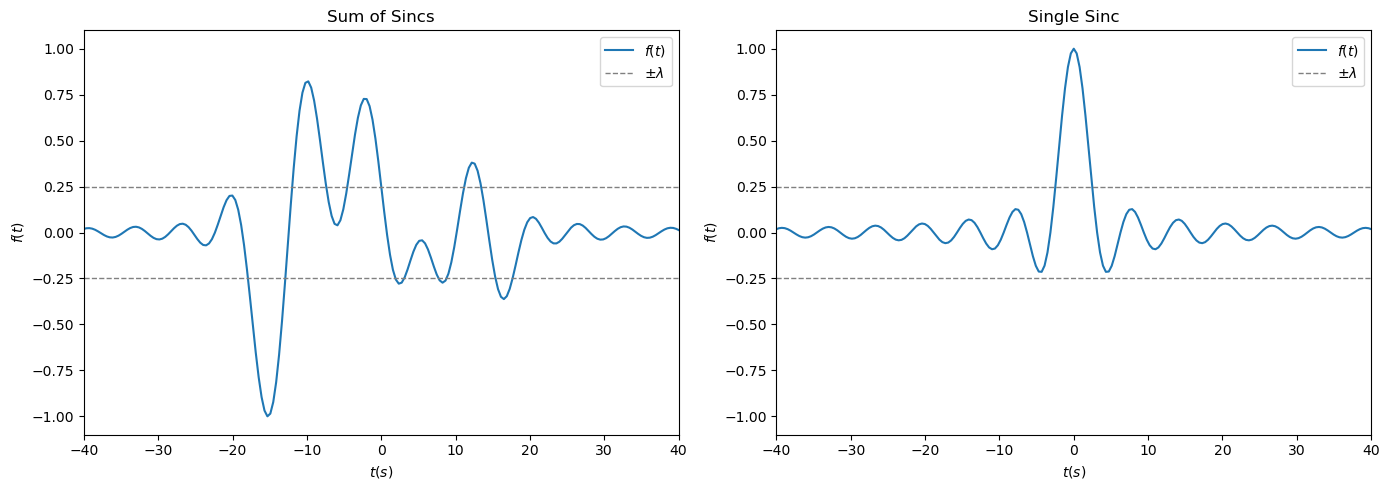

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, t_arr, f_arr, title in [
    (ax1, t, f, "Sum of Sincs"),
    (ax2, t_single_sinc, f_single_sinc, "Single Sinc"),
]:
    ax.plot(t_arr, f_arr, linewidth=1.5, label=r"$f(t)$")
    ax.axhline(+lam, color="grey", linestyle="--", linewidth=1, label=r"$\pm\lambda$")
    ax.axhline(-lam, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel(r"$t(s)$")
    ax.set_ylabel(r"$f(t)$")
    ax.set_title(title)
    ax.legend()

    ax.set_xlim(-40, 40)

    ymax = 1.1
    ax.set_ylim(-ymax, ymax)

plt.tight_layout()
plt.show()

## Non-linear transformations

An ADC with dynamic range $[-\lambda, \lambda]$ cannot represent a signal whose amplitude exceeds $|\lambda|$. Thus, we apply a known non-linear operator before sampling to keep every sample inside the range. The following operators are examples of these transformations:

### Modulo

The modulo operator folds any input back into $[-\lambda, \lambda]$ using the following equation:

$$ \mathcal{M}_\lambda(a) \;=\; (a + \lambda) \bmod 2\lambda \;-\; \lambda $$

In [6]:
def modulo(x, lam):
    return ((x + lam) % (2 * lam)) - lam

### Clipping
Clipping simply clamps the signal to the dynamic range.

$$
C_\lambda(a) =
\begin{cases}
+\lambda, & a > \lambda, \\
a, & |a| \le \lambda, \\
-\lambda, & a < -\lambda.
\end{cases}
$$

In [7]:
def clip(x, lam):
    return np.clip(x, -lam, lam)

### Companding ($\mu$-law) and $\mu$-law Modulo

Companding squashes the signal into the dynamic range with a smooth, invertible function.

The following shows the $\mu$-law compressor and it's inverse (expander):

Compressor:
$$\mathcal{G}_\lambda(x) = \operatorname{sign}(x)\cdot \lambda \cdot \frac{\ln\left(1+\mu|x|/\lambda\right)}{\ln(1+\mu)}$$

Expander: 
$$\mathcal{G}_\lambda^{-1}(y) = \operatorname{sign}(y)\cdot \lambda \cdot \frac{(1+\mu)^{|y|/\lambda}-1}{\mu}$$

In the paper, the operator used is called *$\mu$-law modulo*, a combination of modulo and the $\mu$-law compander. The signal is first folded via modulo and then each sample is companded.

In [ ]:
def mu_law_g(x, lam, mu):
    """Forward mu-law companding"""
    return np.sign(x) * lam * np.log1p(mu * np.abs(x) / lam) / np.log1p(mu)


def mu_law_g_inv(y, lam, mu):
    """Inverse companding (expander); exact inverse of mu_law_g."""
    return np.sign(y) * lam * (np.power(1.0 + mu, np.abs(y) / lam) - 1.0) / mu


def mu_law_modulo(x, lam, mu):
    """Forward mu-law-modulo operator: fold with plain modulo then compand"""
    return mu_law_g(modulo(x, lam), lam, mu)


Visualising the three operators:

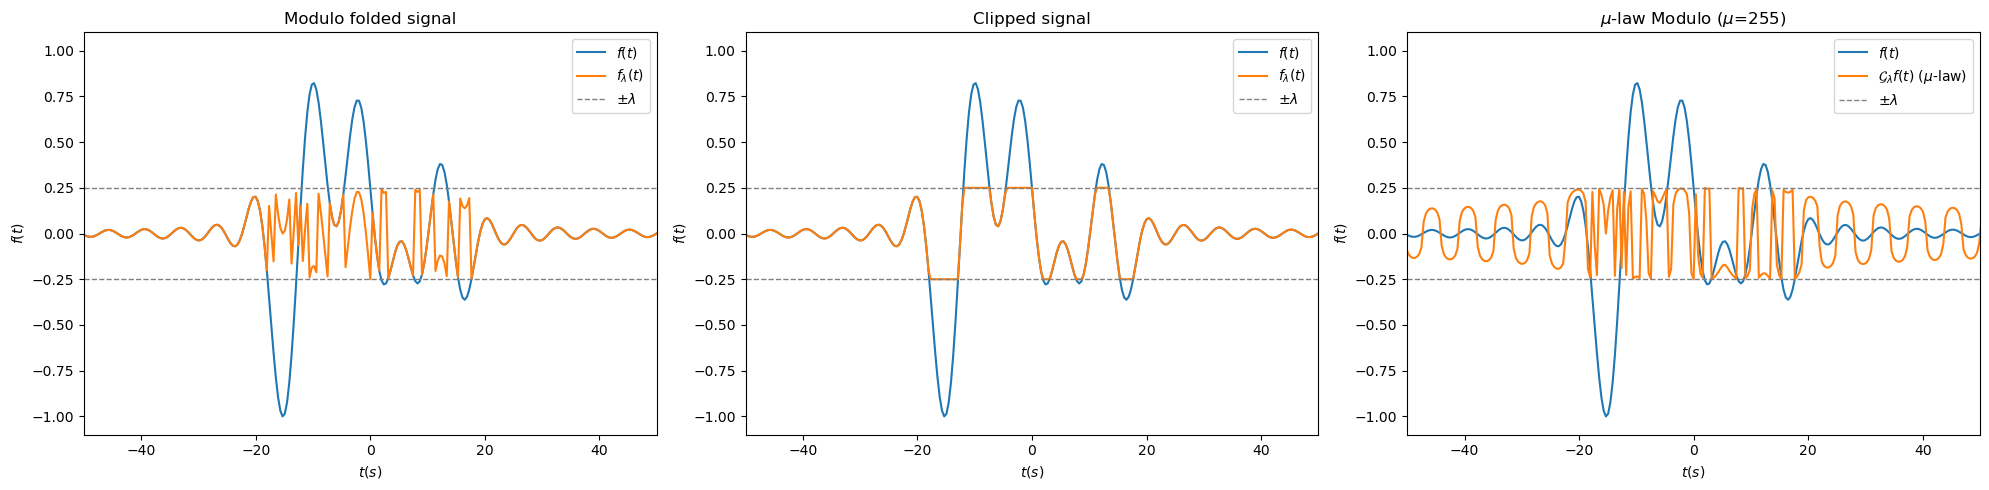

In [9]:
def plot_folded(ax, t, f, f_mod, lam, mod_label, title):
    ax.plot(t, f, linewidth=1.5, label=r"$f(t)$")
    ax.plot(t, f_mod, linewidth=1.5, label=mod_label)

    ax.axhline(+lam, color="grey", linestyle="--", linewidth=1, label=r"$\pm\lambda$")
    ax.axhline(-lam, color="grey", linestyle="--", linewidth=1)

    ax.set_xlabel(r"$t(s)$")
    ax.set_ylabel(r"$f(t)$")
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(-50, 50)

    ymax = 1.1
    ax.set_ylim(-ymax, ymax)


mu = 255.0

specs = [
    (modulo(f, lam), r"$f_\lambda(t)$", "Modulo folded signal"),
    (clip(f, lam), r"$f_\lambda(t)$", "Clipped signal"),
    (mu_law_modulo(f, lam, mu), r"$\mathcal{G}_\lambda f(t)$ ($\mu$-law)", rf"$\mu$-law Modulo ($\mu$={mu:g})"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (f_mod, label, title) in zip(axes, specs):
    plot_folded(ax, t, f, f_mod, lam, label, title)

plt.tight_layout()
plt.show()

## Generalized Operator

Rather than analysing the operators separately, we will work with a single operator that applies to all three.

$$
\mathcal{G}_{\lambda} f(t) =
\begin{cases}
\text{arbitrary}, & |f(t)| > \lambda, \\
g \circ f(t), & |f(t)| \le \lambda.
\end{cases}
$$

Inside the dynamic range, $\mathcal{G}_{\lambda}$ applies a known, continuous and invertible map $g$. Outside of it, the operator may do anything including clipping or modulo folding.

To recover $f$, we first undo the in-range map to get $u(nT_s) := g^{-1}\!\big(f_\lambda(nT_s)\big)$, and define the **residual $z$,** as the gap between these inverted samples and the true ones:

$$
z(nT_s) \;=\; g^{-1}\!\big(f_\lambda(nT_s)\big) - f(nT_s).
$$

For the modulo operator $g$ is the identity, collapsing the above to, 
$$f_\lambda(nT_s) = f(nT_s) + z(nT_s)$$

where the residual follows the following structure:

$$
z(nT_s) \in 2\lambda\,\mathbb{Z}.
$$

Each entry of $z$ is zero where no fold happened and an integer multiple of $2\lambda$ at each fold. We only need to recover $z$ to find the true signal. To do this, we take advantage of two properties, one in time and one in frequency, covered in the next sections.

## Time-domain Separation

According to the Riemann-Lebesgue Lemma, finite-energy bandlimited signals decay. Therefore, there exists some integer $N_\lambda$ beyond which the signal fully lives inside the dynamic range $|f(nT_s)| < \lambda$. This means that the **residual, $z$ is time-limited**: $z(nT_s) = 0$ for all $|n| > N_\lambda$. Thus, $z$ is a vector with at most $2N_\lambda + 1$ nonzero entries, all sitting in a known window in time.

In this report, we shall calculate $N_\lambda$ naively by finding the max absolute index at which the farthest fold happens.

In [10]:
def get_N_lambda_naive(f, lam):
    "Naive way of getting N_lambda by finding the index where the signal is folded last"
    # Grab the length of the signal
    L = len(f)

    # Create the time-step indices
    n_axis = np.arange(-L // 2, L // 2)

    # Create a boolean mask to mark samples that get folded
    is_folded = np.abs(f) > lam

    # Get the max time-step index where this occurs
    N_lam = np.max(np.abs(n_axis[is_folded]))

    return N_lam

N_lam = get_N_lambda_naive(f, lam)

Visualising the separation:

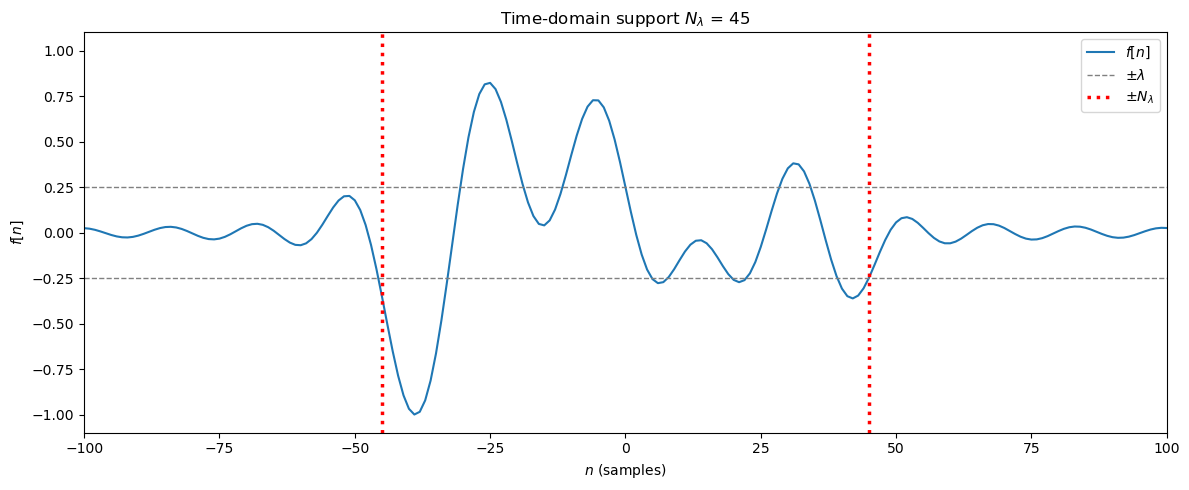

In [11]:
n = np.arange(-len(f)//2, len(f)//2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(n, f, linewidth=1.5, label=r"$f[n]$")
ax.axhline(+lam, color="grey", linestyle="--", linewidth=1, label=r"$\pm\lambda$")
ax.axhline(-lam, color="grey", linestyle="--", linewidth=1)

ax.axvline(+N_lam, color="red", linestyle=":", linewidth=2.5, label=r"$\pm N_\lambda$")
ax.axvline(-N_lam, color="red", linestyle=":", linewidth=2.5)

ax.set_xlabel(r"$n$ (samples)")
ax.set_ylabel(r"$f[n]$")
ax.set_title(f"Time-domain support $N_\lambda$ = {N_lam}")
ax.legend()
ax.set_xlim(-100, 100)
ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

## Frequency-domain Separation

Since we're sampling above the Nyquist Rate, theoretically, the DTFT of the true samples has a region where it is exactly zero, the band-gap ($\rho$).

$$
F(e^{j\omega T_s}) = 0, \qquad \omega_m < |\omega| < \omega_s/2.
$$

By linearity of the DTFT applied to $f_\lambda = f + z$:

$$
F_\lambda(e^{j\omega T_s}) \;=\; Z(e^{j\omega T_s}) \qquad \text{for } \omega_m < |\omega| < \omega_s/2.
$$

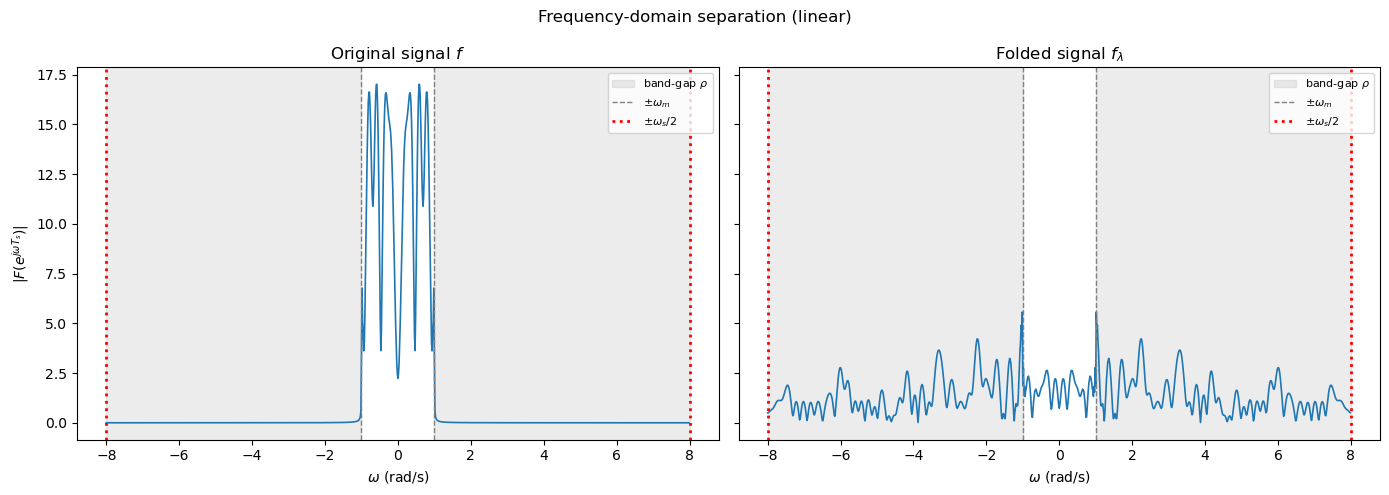

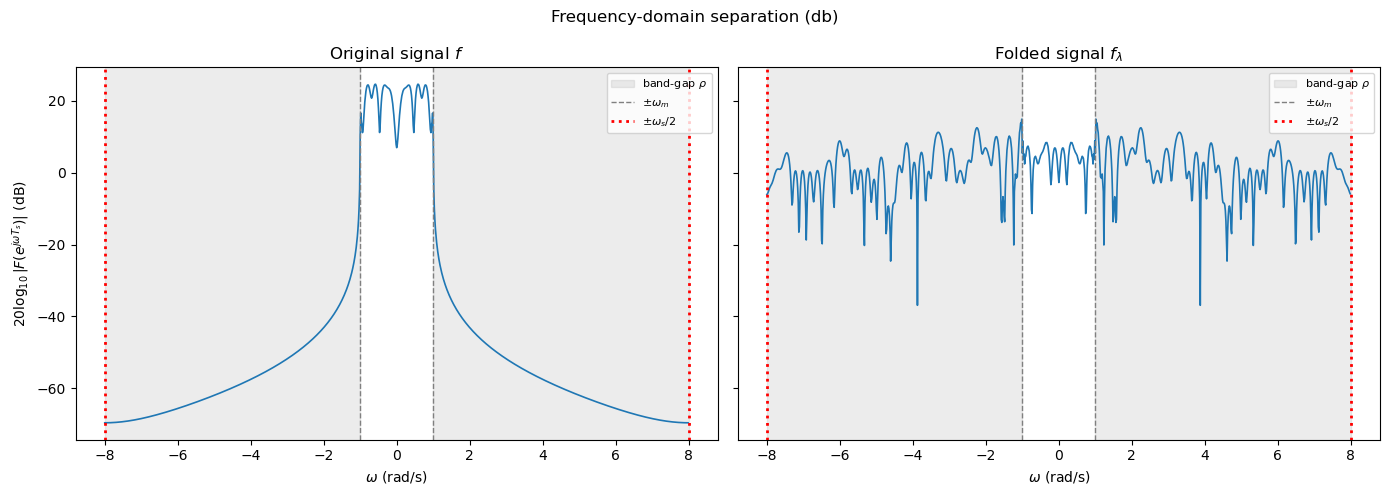

In [12]:
# Visualising the bandgap

f_lam = modulo(f, lam)

omega = np.fft.fftshift(np.fft.fftfreq(len(f), d=Ts)) * 2 * np.pi
F = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(f)))
F_lam = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(f_lam)))


def plot_spectrum_pair(scale):
    """Side-by-side spectra of f (left) and f_lambda (right) for the given scale."""
    if scale == "db":
        y_f, y_lam = 20 * np.log10(np.abs(F)), 20 * np.log10(np.abs(F_lam))
        ylabel = r"$20\log_{10}|F(e^{j\omega T_s})|$ (dB)"
    elif scale == "linear":
        y_f, y_lam = np.abs(F), np.abs(F_lam)
        ylabel = r"$|F(e^{j\omega T_s})|$"

    fig, (ax_f, ax_lam) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, y, title in [
        (ax_f, y_f, r"Original signal $f$"),
        (ax_lam, y_lam, r"Folded signal $f_\lambda$"),
    ]:
        ax.plot(omega, y, linewidth=1.2)

        # Shade the band-gap rho on both sides.
        ax.axvspan(omega_m, omega_s / 2, color="grey", alpha=0.15,
                   label=r"band-gap $\rho$")
        ax.axvspan(-omega_s / 2, -omega_m, color="grey", alpha=0.15)

        # Band edges: +/-omega_m (signal band) and +/-omega_s/2 (Nyquist).
        ax.axvline(+omega_m, color="grey", linestyle="--", linewidth=1,
                   label=r"$\pm\omega_m$")
        ax.axvline(-omega_m, color="grey", linestyle="--", linewidth=1)
        ax.axvline(+omega_s / 2, color="red", linestyle=":", linewidth=2,
                   label=r"$\pm\omega_s/2$")
        ax.axvline(-omega_s / 2, color="red", linestyle=":", linewidth=2)

        ax.set_xlabel(r"$\omega$ (rad/s)")
        ax.set_title(title)
        ax.legend(loc="upper right", fontsize=8)

    ax_f.set_ylabel(ylabel)
    fig.suptitle(f"Frequency-domain separation ({scale})")
    plt.tight_layout()
    plt.show()

plot_spectrum_pair("linear")
plot_spectrum_pair("db")


The above visualisations proves that the spectral energy in the band-gap region $\rho$ comes from the folded signals. Visualising in dB scale however shows a small leak on the original signal and can be attributed to the truncation on the generated signal.

## Matrix-Inversion Solution

The sections above establish the two facts the B2R2 algorithm rests on:
1. The residual $z$ is supported on only $2N_\lambda + 1$ samples (time-limited) and,
2. That only the residual's DTFT can be found on the bandgap region $\rho$. 

Putting those together results in a finite-dimensional inverse problem:

$$
F_\lambda(e^{j\omega T_s}) \;=\; \sum_{n=-N_\lambda}^{N_\lambda} z(nT_s)\, e^{-j n T_s \omega}, \qquad \omega \in \rho := (-\omega_s/2,\,-\omega_m)\cup(\omega_m,\,\omega_s/2).
$$

The left side is computable from the measured samples while the right side is a trigonometric polynomial with $2N_\lambda + 1$ unknown coefficients. With this, we can theoretically solve for the residuals via a simple matrix-inversion.

### Error Metric

Reconstruction quality will be measured by the normalised mean-squared error between the true signal $f$ and its estimate $\hat f$:

$$
\mathrm{NMSE} \;=\; \frac{\lVert f - \hat f\rVert^2}{\lVert f\rVert^2},
$$ 

It will also be reported in decibels, $10\log_{10}(\mathrm{NMSE})$

In [13]:
def matrix_inversion_solve(f_lambda, omega_m, omega_s, Ts, N_lam,
                              os_rho=1.0, sampling="linear", warmup=0.0,
                              seed=None):

    L = len(f_lambda)
    n_axis = np.arange(-L // 2, L // 2)

    n_unknowns = 2 * N_lam + 1
    # Total sample frequencies after oversampling.
    num_total = max(n_unknowns, int(round(os_rho * n_unknowns)))

    # Split across the two bands, keeping the +1 asymmetry on the positive side.
    num_pos = num_total // 2 + (num_total % 2)
    num_neg = num_total - num_pos

    # width of each band
    bw = omega_s / 2 - omega_m 

    def chebyshev_band(lo, hi, num):
        k = np.arange(num)
        return (lo + hi) / 2 + (hi - lo) / 2 * np.cos((2 * k + 1) * np.pi / (2 * num))

    def linear_band(lo, hi, num):
        edges = np.linspace(lo, hi, num + 1)
        return 0.5 * (edges[:-1] + edges[1:])

    def random_band(lo, hi, num, rng):
        pts = rng.uniform(lo, hi, size=num)
        while len(np.unique(pts)) < num:
            pts = rng.uniform(lo, hi, size=num)
        return pts

    # Warm-up: push the inner edge of rho outward by a `warmup` of the band width.
    inner_pos = omega_m + warmup * bw
    inner_neg = -(omega_m + warmup * bw)

    if sampling == "chebyshev":
        omega_pos = chebyshev_band(inner_pos, omega_s / 2, num_pos)
        omega_neg = chebyshev_band(-omega_s / 2, inner_neg, num_neg)

    elif sampling == "linear":
        omega_pos = linear_band(inner_pos, omega_s / 2, num_pos)
        omega_neg = linear_band(-omega_s / 2, inner_neg, num_neg)

    elif sampling == "random":
        rng = np.random.default_rng(seed)
        omega_pos = random_band(inner_pos, omega_s / 2, num_pos, rng)
        omega_neg = random_band(-omega_s / 2, inner_neg, num_neg, rng)

    else:
        raise ValueError(f"unknown sampling={sampling!r}")

    # Total samples
    omega_samples = np.concatenate([omega_neg, omega_pos])

    # Evaluate F_lambda at those frequencies via direct DTFT sum.
    phase = np.outer(n_axis, omega_samples) * Ts          # (L, num_total)
    F_lam_vals = f_lambda @ np.exp(-1j * phase)           # (num_total,)

    # Build the matrix.
    n_z = np.arange(-N_lam, N_lam + 1)                    # (2N+1,)
    M = np.exp(-1j * np.outer(omega_samples, n_z) * Ts)   # (num_total, 2N+1)

    # Solve using least-squares and calculate condition and rank
    cond = np.linalg.cond(M)                              
    rank = np.linalg.matrix_rank(M)
    z_short, *_ = np.linalg.lstsq(M, F_lam_vals, rcond=None)   # (2N+1,)

    # 
    z_full = np.zeros(L, dtype=complex)
    z_full[L // 2 - N_lam : L // 2 + N_lam + 1] = z_short

    # Recover f
    f_hat = f_lambda - z_full.real
    return f_hat, cond, rank

In [14]:
# Setting up the test signal
omega_m_mi_test = 2 * np.pi
OF_mi_test = 6
Ts_mi_test = np.pi / (OF_mi_test * omega_m_mi_test)
omega_s_mi_test = 2 * np.pi / Ts_mi_test
L_mi_test = 1024
f_mi_test, t_mi_test = make_test_signal(L_mi_test, omega_m_mi_test, OF_mi_test, seed=0,
                                  type='single-sinc')

colors = {"linear": "C0", "chebyshev": "C3", "random": "C2"}
lam_show = [0.45, 0.20, 0.15, 0.10]

In [15]:
# Helper functions for plotting and printing of results

def plot_recon_grid(rows, lam_show, row_label, title, panel_color=None):
    """rows: list of (label, kwargs) where kwargs go to matrix_inversion_solve_os.
       panel_color: fixed color, or None to color by rows[i] label via `colors`."""
    n_axis = np.arange(-L_mi_test // 2, L_mi_test // 2)
    win = (n_axis >= -30) & (n_axis <= 30)

    fig, axes = plt.subplots(len(rows), len(lam_show),
                             figsize=(4 * len(lam_show), 3 * len(rows)),
                             sharex=True, sharey=False, squeeze=False)

    for r, (rlabel, kw) in enumerate(rows):
        col = panel_color or colors.get(kw.get("sampling", "linear"), "C0")
        for c, lam_i in enumerate(lam_show):
            ax = axes[r, c]
            N_i = get_N_lambda_naive(f_mi_test, lam_i)
            f_lam_i = modulo(f_mi_test, lam_i)
            f_hat_i, cond_i, rank_i = matrix_inversion_solve(
                f_lam_i, omega_m_mi_test, omega_s_mi_test, Ts_mi_test, N_i,
                seed=0, **kw)
            nmse_i = np.mean((f_mi_test - f_hat_i)**2) / np.mean(f_mi_test**2)

            ax.plot(n_axis[win], f_mi_test[win], "k-", lw=1.5, label="original $f$")
            ax.plot(n_axis[win], f_hat_i[win], "--", color=col, lw=1.5,
                    label="recovered $\\hat{f}$")
            ax.set_title(f"$\\lambda={lam_i}$, $N_\\lambda={N_i}$\n"
                         f"cond={cond_i:.1e}, NMSE={nmse_i:.1e}", fontsize=9)
            if c == 0:
                ax.set_ylabel(f"{rlabel}\n$f(n)$")
            if r == len(rows) - 1:
                ax.set_xlabel("n")
            if r == 0 and c == 0:
                ax.legend(fontsize=8)

    plt.suptitle(title, y=1.005)
    plt.tight_layout()
    plt.show()

def print_recon_table(rows, lam_show, header):
    """rows: list of (label, kwargs) where kwargs go to matrix_inversion_solve_os."""
    print(header)
    for rlabel, kw in rows:
        for lam_i in lam_show:
            N_i = get_N_lambda_naive(f_mi_test, lam_i)
            f_lam_i = modulo(f_mi_test, lam_i)
            f_hat_i, cond_i, rank_i = matrix_inversion_solve(
                f_lam_i, omega_m_mi_test, omega_s_mi_test, Ts_mi_test, N_i,
                seed=0, **kw)
            nmse_i = np.mean((f_mi_test - f_hat_i)**2) / np.mean(f_mi_test**2)
            full = 2 * N_i + 1
            flag = "" if rank_i == full else "  <-- RANK DEFICIENT"
            print(f"  {rlabel:14s}  lam={lam_i:5.2f}  N_lam={N_i:3d}  |  "
                  f"cond={cond_i:.2e}  |  rank={rank_i}/{full}{flag}  |  "
                  f"NMSE={nmse_i:.2e}")
        print()

### Frequency Selection Experiment

We test out various placement schemes to check if these would affect reconstruction quality. These are:

1. Linear - evenly spaced points.
2. Chebyshev - points clustered toward the band edges via the Chebyshev cosine rule.
3. Random - randomly chosen points (with duplicates rejected).

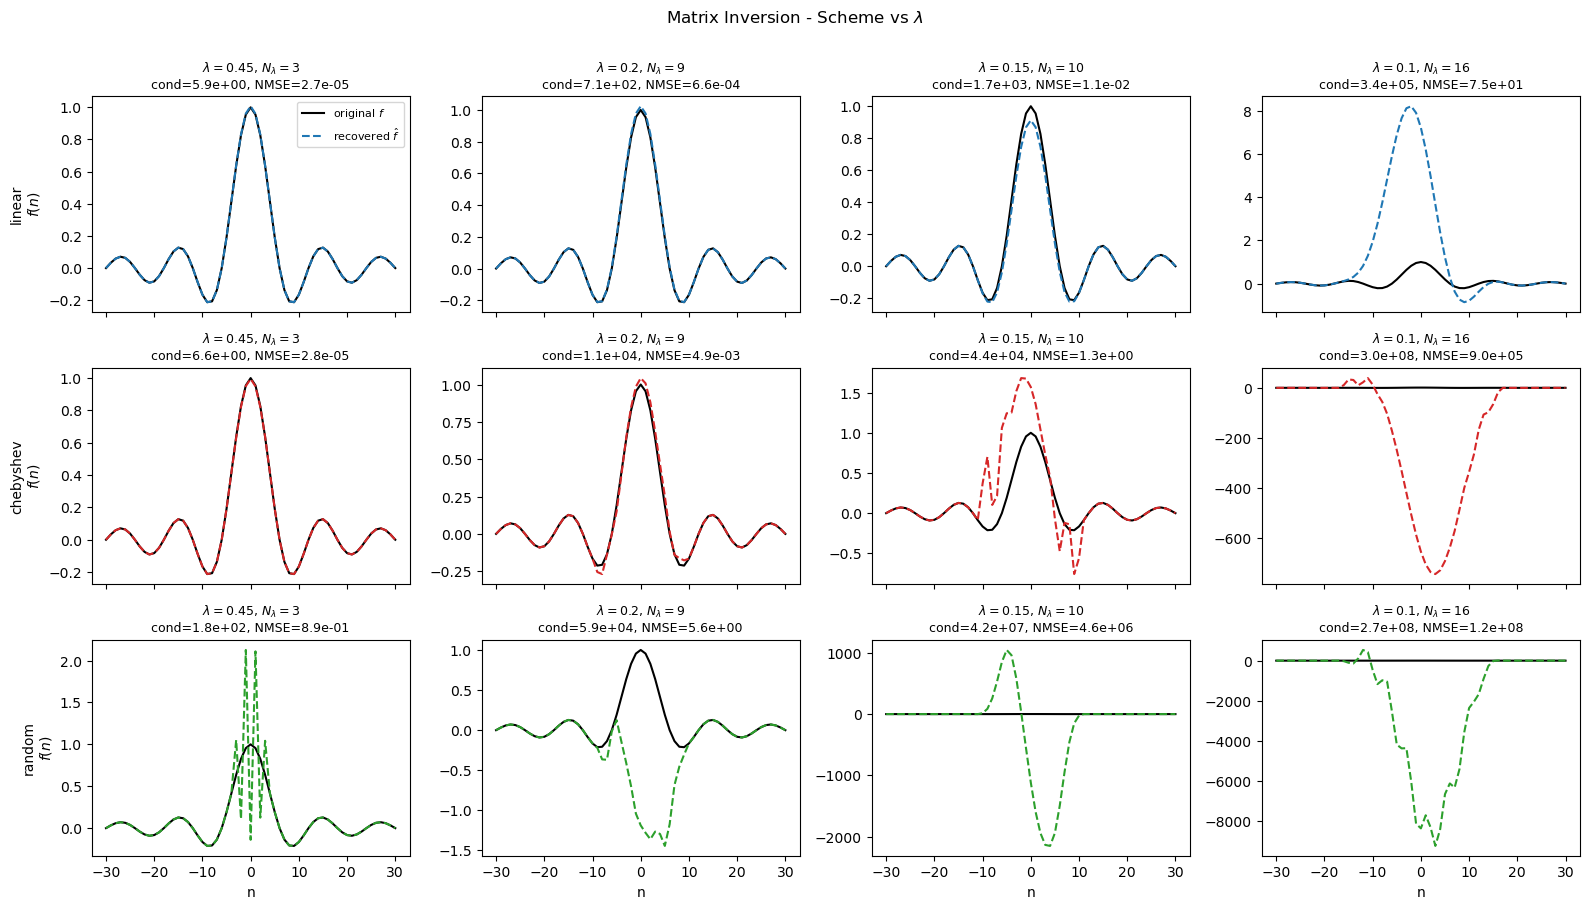

Scheme vs Lambda
  linear          lam= 0.45  N_lam=  3  |  cond=5.93e+00  |  rank=7/7  |  NMSE=2.72e-05
  linear          lam= 0.20  N_lam=  9  |  cond=7.09e+02  |  rank=19/19  |  NMSE=6.60e-04
  linear          lam= 0.15  N_lam= 10  |  cond=1.68e+03  |  rank=21/21  |  NMSE=1.05e-02
  linear          lam= 0.10  N_lam= 16  |  cond=3.39e+05  |  rank=33/33  |  NMSE=7.47e+01

  chebyshev       lam= 0.45  N_lam=  3  |  cond=6.59e+00  |  rank=7/7  |  NMSE=2.81e-05
  chebyshev       lam= 0.20  N_lam=  9  |  cond=1.06e+04  |  rank=19/19  |  NMSE=4.86e-03
  chebyshev       lam= 0.15  N_lam= 10  |  cond=4.41e+04  |  rank=21/21  |  NMSE=1.27e+00
  chebyshev       lam= 0.10  N_lam= 16  |  cond=2.97e+08  |  rank=33/33  |  NMSE=9.04e+05

  random          lam= 0.45  N_lam=  3  |  cond=1.84e+02  |  rank=7/7  |  NMSE=8.93e-01
  random          lam= 0.20  N_lam=  9  |  cond=5.91e+04  |  rank=19/19  |  NMSE=5.56e+00
  random          lam= 0.15  N_lam= 10  |  cond=4.19e+07  |  rank=21/21  |  NMSE=4.60e+

In [16]:
plot_recon_grid(
    rows=[(s, dict(os_rho=1.0, sampling=s, warmup=0.0)) for s in
          ["linear", "chebyshev", "random"]],
    lam_show=lam_show, row_label="scheme",
    title="Matrix Inversion - Scheme vs $\\lambda$")

print_recon_table(
    rows=[(s, dict(os_rho=1.0, sampling=s, warmup=0.0)) for s in
          ["linear", "chebyshev", "random"]],
    lam_show=lam_show,
    header="Scheme vs Lambda")

We can see that the matrix inversion can indeed reconstruct the original signal in some cases. Linear point placement performs best with a good reconstruction until $N_\lambda = 9$ and starts failing at higher $N_\lambda$. Chebyshev point placement loses conditioning earlier due to the condensed position of the points at the band edges while random point placement was not able to recreate the signal even at the lowest $N_\lambda$.

### Warm-up at $\rho$

Due to the truncation of the sinc test signal, there is a slight spectral leak at the inner edges of $\rho$. In this, we test adding a warm-up period, to push out that inner edge and avoid the leak.

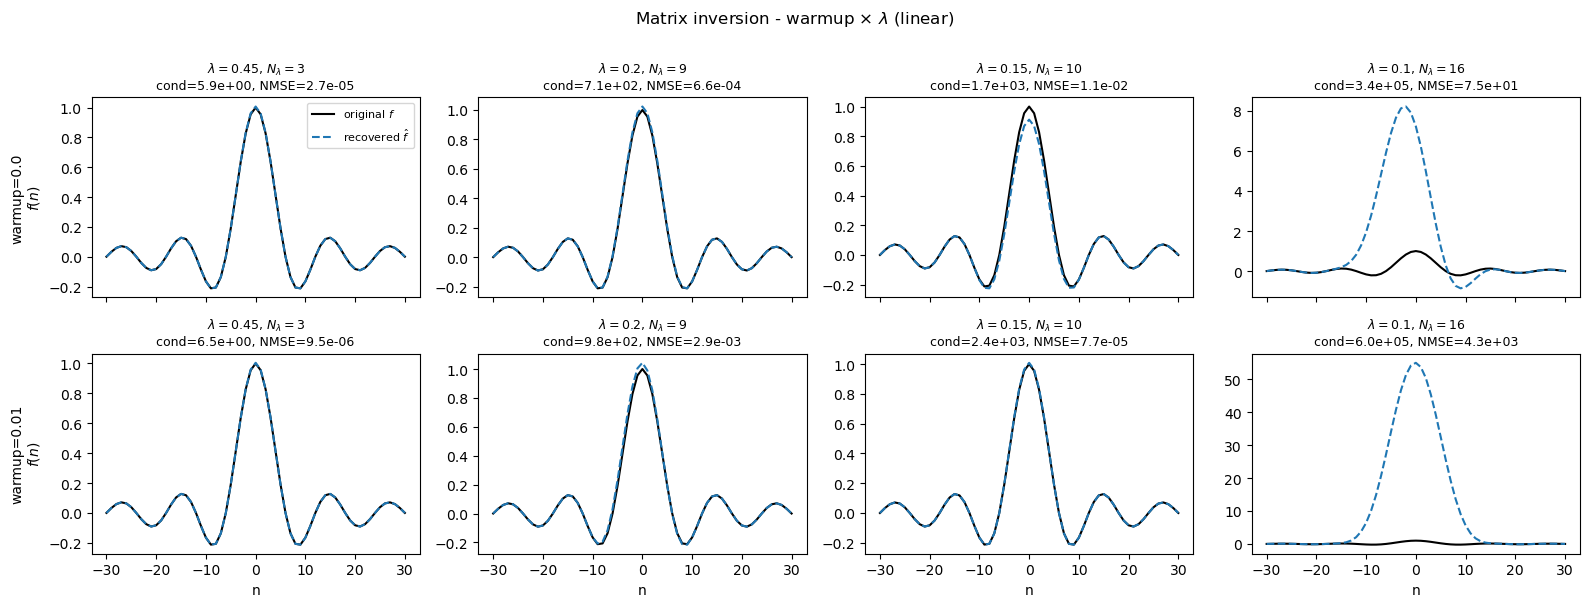

warmup vs lambda (linear)
  warmup=0.0      lam= 0.45  N_lam=  3  |  cond=5.93e+00  |  rank=7/7  |  NMSE=2.72e-05
  warmup=0.0      lam= 0.20  N_lam=  9  |  cond=7.09e+02  |  rank=19/19  |  NMSE=6.60e-04
  warmup=0.0      lam= 0.15  N_lam= 10  |  cond=1.68e+03  |  rank=21/21  |  NMSE=1.05e-02
  warmup=0.0      lam= 0.10  N_lam= 16  |  cond=3.39e+05  |  rank=33/33  |  NMSE=7.47e+01

  warmup=0.01     lam= 0.45  N_lam=  3  |  cond=6.53e+00  |  rank=7/7  |  NMSE=9.48e-06
  warmup=0.01     lam= 0.20  N_lam=  9  |  cond=9.81e+02  |  rank=19/19  |  NMSE=2.87e-03
  warmup=0.01     lam= 0.15  N_lam= 10  |  cond=2.42e+03  |  rank=21/21  |  NMSE=7.75e-05
  warmup=0.01     lam= 0.10  N_lam= 16  |  cond=6.02e+05  |  rank=33/33  |  NMSE=4.32e+03



In [17]:
plot_recon_grid(
    rows=[(f"warmup={w}", dict(os_rho=1.0,sampling="linear", warmup=w))
          for w in [0.0, 0.01]],
    lam_show=lam_show, row_label="warmup",
    title="Matrix inversion - warmup × $\\lambda$ (linear)",
    panel_color="C0")

print_recon_table(
    rows=[(f"warmup={w}", dict(os_rho=1.0, sampling="linear", warmup=w))
          for w in [0.0, 0.01]],
    lam_show=lam_show,
    header="warmup vs lambda (linear)")

Adding a warm-up period of 0.01, improves performance for some lower $N_\lambda$ cases but the overall reconstruction still breaks down at higher $N_\lambda$. A higher warm-up period (testing out 0.1) degrades performance even for lower $N_\lambda$, so there is a trade-off in avoiding the spectral leak of the original signal and the retaining of points to use for the solution.

## Increasing sample points in $\rho$

The $2N_\lambda + 1$ number of frequencies needed in $\rho$ is the theoretical minimimum but is not a hard constraint. Testing out using more point in $\rho$ shows the following:

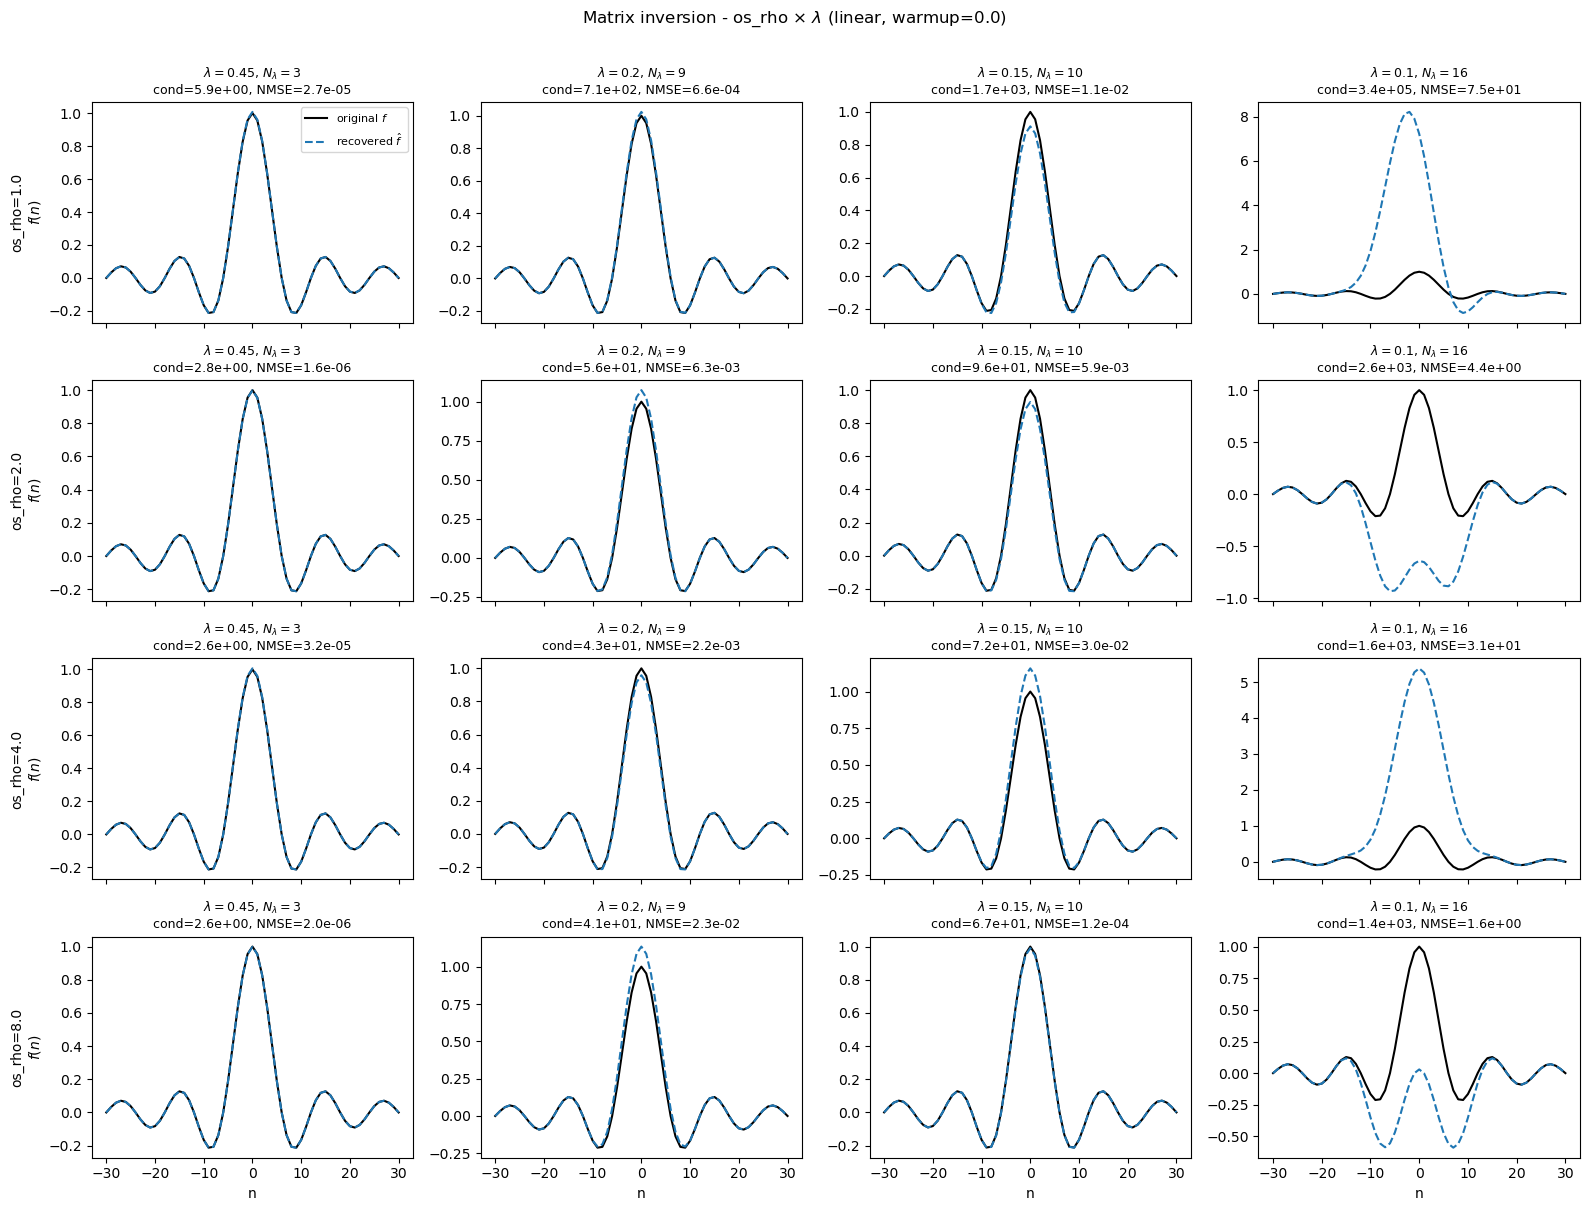

oversampling rho × lambda (linear, warmup=0.0)
  os_rho=1.0      lam= 0.45  N_lam=  3  |  cond=5.93e+00  |  rank=7/7  |  NMSE=2.72e-05
  os_rho=1.0      lam= 0.20  N_lam=  9  |  cond=7.09e+02  |  rank=19/19  |  NMSE=6.60e-04
  os_rho=1.0      lam= 0.15  N_lam= 10  |  cond=1.68e+03  |  rank=21/21  |  NMSE=1.05e-02
  os_rho=1.0      lam= 0.10  N_lam= 16  |  cond=3.39e+05  |  rank=33/33  |  NMSE=7.47e+01

  os_rho=2.0      lam= 0.45  N_lam=  3  |  cond=2.80e+00  |  rank=7/7  |  NMSE=1.65e-06
  os_rho=2.0      lam= 0.20  N_lam=  9  |  cond=5.58e+01  |  rank=19/19  |  NMSE=6.30e-03
  os_rho=2.0      lam= 0.15  N_lam= 10  |  cond=9.60e+01  |  rank=21/21  |  NMSE=5.89e-03
  os_rho=2.0      lam= 0.10  N_lam= 16  |  cond=2.63e+03  |  rank=33/33  |  NMSE=4.38e+00

  os_rho=4.0      lam= 0.45  N_lam=  3  |  cond=2.64e+00  |  rank=7/7  |  NMSE=3.19e-05
  os_rho=4.0      lam= 0.20  N_lam=  9  |  cond=4.32e+01  |  rank=19/19  |  NMSE=2.19e-03
  os_rho=4.0      lam= 0.15  N_lam= 10  |  cond=7.19e+01 

In [18]:
plot_recon_grid(
    rows=[(f"os_rho={r}", dict(os_rho=r, sampling="linear", warmup=0.0))
          for r in [1.0, 2.0, 4.0, 8.0]],
    lam_show=lam_show, row_label="os_rho",
    title="Matrix inversion - os_rho × $\\lambda$ (linear, warmup=0.0)",
    panel_color="C0")

print_recon_table(
    rows=[(f"os_rho={r}", dict(os_rho=r, sampling="linear", warmup=0.0))
          for r in [1.0, 2.0, 4.0, 8.0]],
    lam_show=lam_show,
    header="oversampling rho × lambda (linear, warmup=0.0)")

Even with oversampling, the matrix-inverse solution still breaks down at higher $N_\lambda$. It is clear that for the small support range, the solution is able to recover the signal cleanly but as $N_\lambda$ grows then the matrix used becomes progressively ill-conditioned. 

## $B^2R^2$ Algorithm

We have established that while the direct matrix inversion can recover the residuals in principle, it is fairly limited due to conditioning issues as $N_\lambda$ gets larger. The paper proposes to solve this residual problem through an iterative gradient descent method named $B^2R^2$, which stands for Beyond Bandwidth Residual Reconstruction.



### Highpass operator $\mathcal{F}_\rho^* \mathcal{F}_\rho$

Before we discuss the actual implementation loop, we introduce the operator $\mathcal{F}_\rho^* \mathcal{F}_\rho$

$\mathcal{F}_\rho^* \mathcal{F}_\rho$ is an ideal highpass filter. It zeroes out frequencies inside the signal band and preserves everything in the band-gap.

To do this, we FFT the sequence, zero out the frequencies where $|\omega| \le \omega_m$ and do the inverse FFT.

In [19]:
def highpass_rho(f_centred, omega_m, Ts):

    L = len(f_centred)

    # Centred frequency axis in rad/s
    omega = np.fft.fftshift(np.fft.fftfreq(L, d=Ts)) * 2 * np.pi

    # FFT, centred-in -> centred-out.
    F = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(f_centred)))

    # Zero the in-band region
    F[np.abs(omega) <= omega_m] = 0.0

    # Inverse FFT
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(F)))


print("Verification:")

hp_f = highpass_rho(f, omega_m, Ts)
print(f"max|highpass_rho(f)| = {np.max(np.abs(hp_f)):.2e}  "
      "(small leak due to the truncation of the test signal)")

f_lam_check = modulo(f, lam)
hp_flam = highpass_rho(f_lam_check, omega_m, Ts)
print(f"max|highpass_rho(f_lam)| = {np.max(np.abs(hp_flam)):.4f}  (expected nonzero)")

Verification:
max|highpass_rho(f)| = 6.48e-03  (small leak due to the truncation of the test signal)
max|highpass_rho(f_lam)| = 0.2985  (expected nonzero)


### PGD inner update

Recovery of the residuals is posed as an optimization problem:

$$
\min_{\mathbf{z}} \;\; \tfrac{1}{2}\,\big\|\mathcal{F}_\rho \mathbf{f}_\lambda - \mathcal{F}_\rho \mathbf{z}\big\|^2
\quad \text{s.t.} \quad \mathbf{z} \in \mathcal{S}_{N_\lambda},
$$

where $\mathcal{S}_{N_\lambda}$ is the space of samples supported on $\{-N_\lambda, \dots, N_\lambda\}$.

The projected gradient descent update is then

$$
\begin{aligned}
\mathbf{y}^{k}
&=
\mathbf{z}^{k-1}
-
\gamma\,
\mathcal{F}_{\rho}^{*}\mathcal{F}_{\rho}
\left(
\mathbf{z}^{k-1}
-
\hat{\mathbf{f}}
\right),
\\[4pt]
\mathbf{z}^{k}
&=
P_{\mathcal{S}_{N_\lambda}}
\left(
\mathbf{y}^{k}
\right),
\end{aligned}
$$

where $\gamma$ is the gradient step size (set as 1 in this implementation) and  
$P_{\mathcal{S}_{N_\lambda}}$ is the projection that zeros out all samples outside the support window.

In [20]:
def project_to_support(y, N_lam):
    """Zero everything outside the centred window [-N_lam, N_lam]."""
    center = len(y) // 2
    z = np.zeros_like(y)
    z[center - N_lam : center + N_lam + 1] = y[center - N_lam : center + N_lam + 1]
    return z

def pgd_step(z, f_lambda, omega_m, Ts, N_lam, gamma=1.0):
    """One projected-gradient-descent step for the B2R2 inner loop"""

    # Gradient: nabla C(z) = High-pass filter of (z - f_lambda)
    grad = highpass_rho(z - f_lambda, omega_m, Ts)

    # Gradient step: move against the gradient.
    y = z - gamma * grad

    # Projection P_{S_{N_lam}}: zero everything outside [-N_lam, N_lam].
    z_new = project_to_support(y, N_lam)

    return z_new

def init_z(f_lambda, omega_m, Ts, N_lam):
    """Initialize z"""
    hp = highpass_rho(f_lambda, omega_m, Ts)
    z0 = project_to_support(hp, N_lam)
    return z0

# Testing out
f_lam = modulo(f, lam)
z0 = init_z(f_lam, omega_m, Ts, N_lam)
z1 = pgd_step(z0, f_lam, omega_m, Ts, N_lam)

def pgd_cost(z, f_lambda, omega_m, Ts):
    """Cost C(z) = 0.5 * ||F_rho(z - f_lambda)||^2"""
    residual = highpass_rho(z - f_lambda, omega_m, Ts)
    return 0.5 * np.sum(np.abs(residual)**2)


print("Checking cost after one step:\n")
c0 = pgd_cost(z0, f_lam, omega_m, Ts)
c1 = pgd_cost(z1, f_lam, omega_m, Ts)
print(f"Cost before step: {c0:.6f}")
print(f"Cost after step:  {c1:.6f}")
print("Cost decreased.")

Checking cost after one step:

Cost before step: 0.119571
Cost after step:  0.085378
Cost decreased.


### Bare PGD (No Outer Loop)

Before creating the full algorithm, we run the inner loop on its own and show how the reconstruction happens in a one-shot scenario.

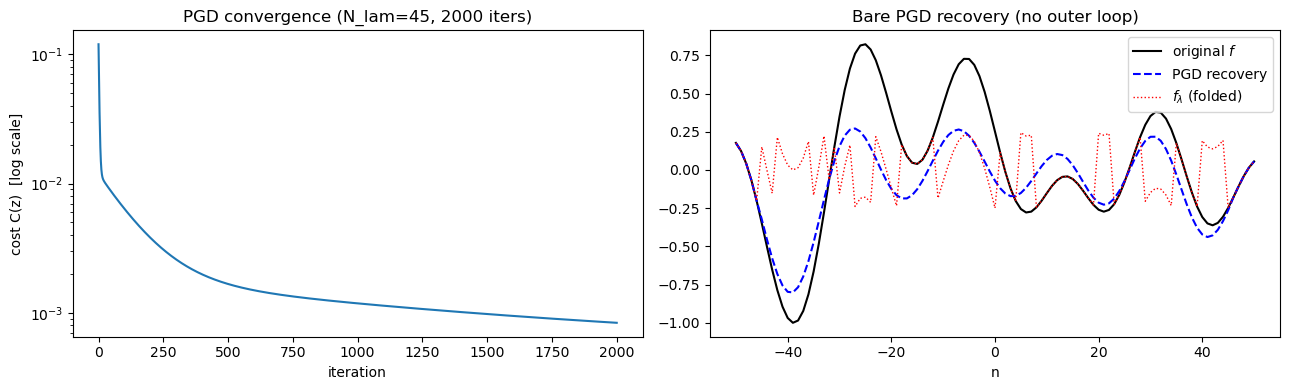

Bare PGD NMSE: 3.51e-01  (-4.5 dB)


In [21]:
def run_pgd(f_lambda, omega_m, Ts, N_lam, max_iters=1000, gamma=1.0):
    """Run PGD at fixed N_lam until cost converges or max_iters."""

    z = init_z(f_lambda, omega_m, Ts, N_lam)
    costs = []
    costs.append(pgd_cost(z, f_lambda, omega_m, Ts))

    for _ in range(max_iters):
        z_new = pgd_step(z, f_lambda, omega_m, Ts, N_lam, gamma)
        c = pgd_cost(z_new, f_lambda, omega_m, Ts)
        costs.append(c)
        z = z_new

    return z_new, costs


# Test run
f_lam = modulo(f, lam)
z_pgd, costs_pgd = run_pgd(f_lam, omega_m, Ts, N_lam, max_iters=2000)
f_hat_pgd = f_lam - z_pgd.real

# Converge plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(costs_pgd)
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("cost C(z)  [log scale]")
axes[0].set_title(f"PGD convergence (N_lam={N_lam}, {len(costs_pgd)-1} iters)")

# Recovery
win = (np.arange(-L//2, L//2) >= -N_lam-5) & (np.arange(-L//2, L//2) <= N_lam+5)
n_win = np.arange(-L//2, L//2)[win]
axes[1].plot(n_win, f[win], "k-",  lw=1.5, label="original $f$")
axes[1].plot(n_win, f_hat_pgd[win], "b--", lw=1.5, label="PGD recovery")
axes[1].plot(n_win, f_lam[win], "r:", lw=1, label=r"$f_\lambda$ (folded)")
axes[1].set_xlabel("n")
axes[1].set_title("Bare PGD recovery (no outer loop)")
axes[1].legend()

plt.tight_layout()
plt.show()

nmse_pgd = np.mean((f - f_hat_pgd)**2) / np.mean(f**2)
print(f"Bare PGD NMSE: {nmse_pgd:.2e}  ({10*np.log10(nmse_pgd):.1f} dB)")

We can see from the plot that for the bare PGD loop, the overall cost function drops rapidly and that the residual reconstruction from the outer edges of the support are more accurate than the ones in the center of the signal. 

### Full B²R² Algorithm

In the full implementation of the algorithm, instead of using the whole PGD estimate, each pass only trusts the support-boundary samples, subtracts them and shrinks the support on each side. The process is as follows:

1. Run the inner PGD loop at the current $N_\lambda$ until max iterations or convergence
2. Project the estimate to the residual's known structure (e.g. for modulo, round to $2\lambda\mathbb{Z}$)
3. Update $\hat{\mathbf{f}} \leftarrow \hat{\mathbf{f}} - \hat{\mathbf{z}}$
4. Subtract $N_\lambda$ by 1
5. Repeat until $N_\lambda = 0$

As a stopping criterion for the inner loop, we keep track of the values on the support edges and stops early once those values have settled to a stated tolerance.

In [22]:
def b2r2(f_lambda, omega_m, Ts, N_lam_init, lam, operator="modulo",
         inner_iters=100, gamma=1.0, edge_tol=1e-5, patience=5, mu=None):
    """ Full B2R2 implementation with N_lambda support peeling."""
    L = len(f_lambda)
    N_lam = N_lam_init

    if operator == "mu_law_modulo":
        f_hat = mu_law_g_inv(f_lambda, lam, mu).astype(complex)
    else:
        f_hat = f_lambda.copy().astype(complex)

    iters_used = []                       
    while N_lam > 0:
        # Initialise z with the current support
        z = init_z(f_hat, omega_m, Ts, N_lam)

        # Inner PGD loop with edge-stability stopping
        edge_prev = _edge_values(z, N_lam)
        stable = 0
        for k in range(inner_iters):
            z = pgd_step(z, f_hat, omega_m, Ts, N_lam, gamma)
            edge_curr = _edge_values(z, N_lam)
            if np.max(np.abs(edge_curr - edge_prev)) < edge_tol:
                stable += 1
                if stable >= patience:
                    break
            else:
                stable = 0
            edge_prev = edge_curr
        iters_used.append(k + 1)

        # Project residual onto the per-operator structure (Algorithm 1, Step 10)
        z_struct = apply_residual_structure(z, f_lambda, lam, operator)

        # Subtract the recovered residual
        f_hat = f_hat - z_struct

        # Peel off the outer supports
        N_lam -= 1

    return f_hat.real, iters_used

def _edge_values(z, N_lam):
    """Residual estimate at the current support boundary (+/- N_lam)."""
    zr = z.real
    center = len(zr) // 2
    return np.array([zr[center - N_lam], zr[center + N_lam]])

def apply_residual_structure(z, f_lambda, lam, operator):
    zr = z.real

    if operator in ('modulo', 'mu_law_modulo'):
        return np.round(zr / (2 * lam)) * (2 * lam)

    elif operator == 'clipping':
        hi = f_lambda.real >=  lam 
        lo = f_lambda.real <= -lam  
        z_struct = np.zeros_like(zr)
        z_struct[hi] = np.minimum(0.0, zr[hi])
        z_struct[lo] = np.maximum(0.0, zr[lo])
        return z_struct

# Running B2R2 on a modulo folded test signal 
f_lam = modulo(f, lam)
f_hat_b2r2, iters_used = b2r2(f_lam, omega_m, Ts, N_lam, lam, operator="modulo", inner_iters=1000)

nmse_b2r2 = np.mean((f - f_hat_b2r2)**2) / np.mean(f**2)
print(f"B2R2 NMSE: {nmse_b2r2:.2e}  ({10*np.log10(nmse_b2r2+1e-20):.1f} dB)")

B2R2 NMSE: 1.12e-32  (-200.0 dB)


### Visualising Recovery on Test Signal

Testing the algorithm against modulo folded samples in our sum-of-sincs test signal:

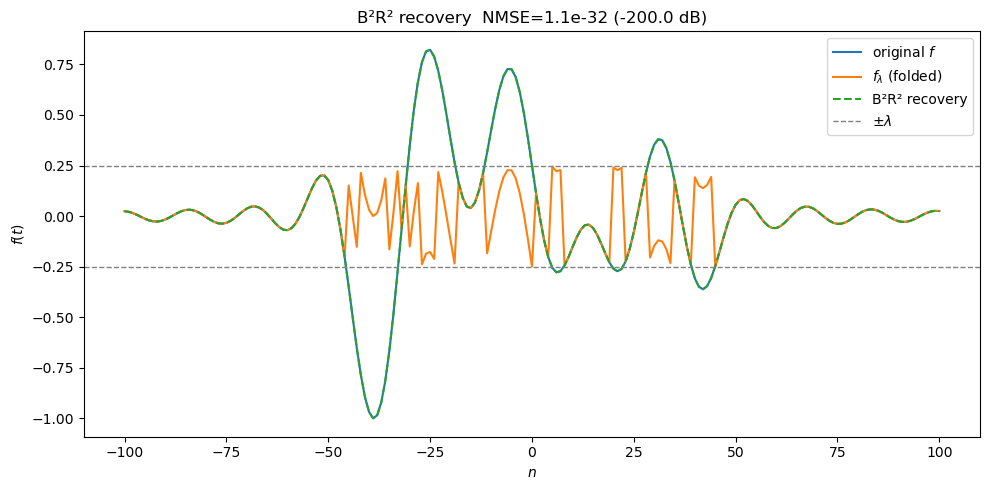

In [23]:
n_axis = np.arange(-L // 2, L // 2)
win = (n_axis >= -100) & (n_axis <= 100)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_axis[win], f[win], linewidth=1.5, label=r"original $f$")
ax.plot(n_axis[win], f_lam[win], linewidth=1.5, label=r"$f_\lambda$ (folded)")
ax.plot(n_axis[win], f_hat_b2r2[win], "--", linewidth=1.5, label="B²R² recovery")

ax.axhline(+lam, color="grey", linestyle="--", linewidth=1, label=r"$\pm\lambda$")
ax.axhline(-lam, color="grey", linestyle="--", linewidth=1)

ax.set_xlabel(r"$n$")
ax.set_ylabel(r"$f(t)$")
ax.set_title(f"B²R² recovery  NMSE={nmse_b2r2:.1e} ({10*np.log10(nmse_b2r2+1e-20):.1f} dB)")
ax.legend()

plt.tight_layout()
plt.show()

We can see that the $B^2R^2$ algorithm fully reconstructs the original signal.

### Comparison between $B^2R^2$ vs Matrix Inversion

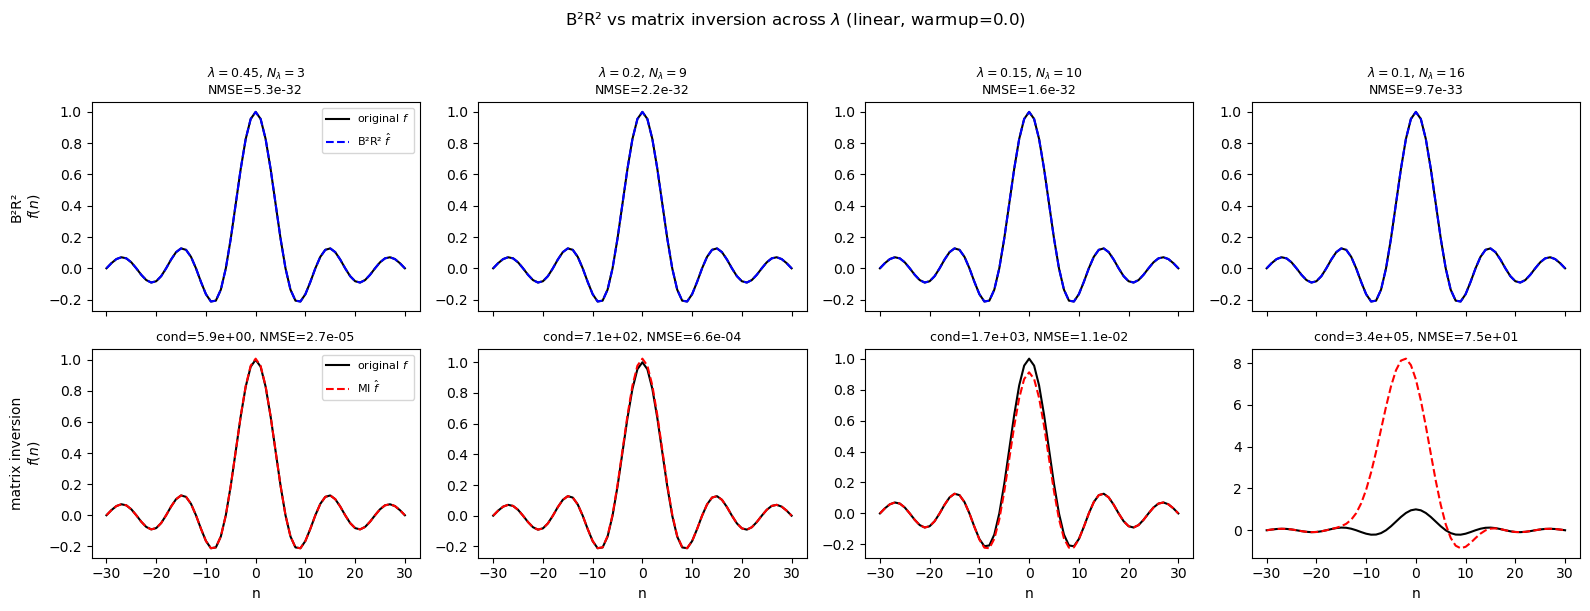

  lambda  N_lam    NMSE B2R2      NMSE MI      cond(M)
    0.45      3     5.34e-32     2.72e-05     5.93e+00
    0.20      9     2.25e-32     6.60e-04     7.09e+02
    0.15     10     1.64e-32     1.05e-02     1.68e+03
    0.10     16     9.74e-33     7.47e+01     3.39e+05


In [24]:
# B²R² vs matrix inversion sweep across lambda (linear sampling only).
lam_sweep = [0.45, 0.20, 0.15, 0.10]
sampling = "linear"
warmup = 0.0

n_axis_mi_test = np.arange(-L_mi_test // 2, L_mi_test // 2)
win = (n_axis_mi_test >= -30) & (n_axis_mi_test <= 30)

results = []  # (lam, N, nmse_b2r2, nmse_mi, cond)

fig, axes = plt.subplots(2, len(lam_sweep),
                         figsize=(4 * len(lam_sweep), 6),
                         sharex=True, sharey=False)

for c, lam_i in enumerate(lam_sweep):
    N_i = get_N_lambda_naive(f_mi_test, lam_i)
    f_lam_i = modulo(f_mi_test, lam_i)

    # B2R2 recovery.
    f_hat_b, _ = b2r2(f_lam_i, omega_m_mi_test, Ts_mi_test, N_i, lam_i, operator="modulo",
                          inner_iters=150)
    nmse_b = np.mean((f_mi_test - f_hat_b)**2) / np.mean(f_mi_test**2)

    # Matrix inversion recovery.
    f_hat_m, cond_m, rank_m = matrix_inversion_solve(
        f_lam_i, omega_m_mi_test, omega_s_mi_test, Ts_mi_test, N_i,
        sampling=sampling, warmup=warmup, seed=0)
    nmse_m = np.mean((f_mi_test - f_hat_m)**2) / np.mean(f_mi_test**2)

    results.append((lam_i, N_i, nmse_b, nmse_m, cond_m))

    # Top row: B2R2.
    ax = axes[0, c]
    ax.plot(n_axis_mi_test[win], f_mi_test[win], "k-", lw=1.5, label="original $f$")
    ax.plot(n_axis_mi_test[win], f_hat_b[win], "b--", lw=1.5, label="B²R² $\\hat{f}$")
    ax.set_title(f"$\\lambda={lam_i}$, $N_\\lambda={N_i}$\nNMSE={nmse_b:.1e}",
                 fontsize=9)
    if c == 0:
        ax.set_ylabel("B²R²\n$f(n)$")
        ax.legend(fontsize=8)

    # Bottom row: matrix inversion.
    ax = axes[1, c]
    ax.plot(n_axis_mi_test[win], f_mi_test[win], "k-", lw=1.5, label="original $f$")
    ax.plot(n_axis_mi_test[win], f_hat_m[win], "r--", lw=1.5,
            label="MI $\\hat{f}$")
    ax.set_title(f"cond={cond_m:.1e}, NMSE={nmse_m:.1e}", fontsize=9)
    ax.set_xlabel("n")
    if c == 0:
        ax.set_ylabel(f"matrix inversion\n$f(n)$")
        ax.legend(fontsize=8)

plt.suptitle(f"B²R² vs matrix inversion across $\\lambda$ (linear, warmup={warmup})",
             y=1.01)
plt.tight_layout()
plt.show()

# Summary table.
print(f"{'lambda':>8} {'N_lam':>6} {'NMSE B2R2':>12} {'NMSE MI':>12} {'cond(M)':>12}")
for lam_i, N_i, nb, nm, cm in results:
    print(f"{lam_i:>8.2f} {N_i:>6d} {nb:>12.2e} {nm:>12.2e} {cm:>12.2e}")

The $B^2R^2$ solution was able to perfectly reconstruct signals that matrix-inversion was too ill-conditioned to solve.

## Comparison of Operators

We now test the algorithm against the three non-linear operators, sweeping across oversampling factor (`OF`), bandwidth (`omega_m`) and dynamic range (`lambda`).

Results are saved to disk (keyed to all parameters) to save on calculation time.

In [25]:
OF_sweep      = [2, 4, 6, 8, 10, 16]
omega_m_sweep = [1.0, 2.0, 3.0]
lam_sweep     = [0.45, 0.20, 0.15, 0.10]
L_cmp         = 1024
seed_cmp      = 42
inner_iters   = 1000
mu            = 255.0

CACHE_PATH = "of_comparison_cache.pkl"    
CSV_PATH   = "of_comparison_summary.csv"  

cache = {}
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as fh:
        cache = pickle.load(fh)

n_skipped = n_computed = 0
for OF_i, omega_m_i, lam_i in itertools.product(OF_sweep, omega_m_sweep, lam_sweep):
    key  = (OF_i, omega_m_i, lam_i)
    prev = cache.get(key)
    
    if prev is not None and (prev["seed"], prev["inner_iters"], prev["mu"], prev["L"]) \
                            == (seed_cmp, inner_iters, mu, L_cmp):
        n_skipped += 1
        continue

    Ts_i   = np.pi / (OF_i * omega_m_i)
    f_i, _ = make_test_signal(L_cmp, omega_m_i, OF_i, seed_cmp, 'sum-of-sincs')
    N_i    = get_N_lambda_naive(f_i, lam_i)

    # Modulo, clipping and mu-law each receive their own non-linear samples.
    f_mod_i   = modulo(f_i, lam_i)
    f_clip_i  = clip(f_i, lam_i)
    f_mulaw_i = mu_law_modulo(f_i, lam_i, mu)

    f_hat_mod, _   = b2r2(f_mod_i,   omega_m_i, Ts_i, N_i, lam_i,
                          operator="modulo",        inner_iters=inner_iters)
    f_hat_clip, _  = b2r2(f_clip_i,  omega_m_i, Ts_i, N_i, lam_i,
                          operator="clipping",      inner_iters=inner_iters)
    f_hat_mulaw, _ = b2r2(f_mulaw_i, omega_m_i, Ts_i, N_i, lam_i,
                          operator="mu_law_modulo", mu=mu, inner_iters=inner_iters)

    cache[key] = {
        "OF": OF_i, "omega_m": omega_m_i, "lam": lam_i, "N_lam": N_i,
        "seed": seed_cmp, "inner_iters": inner_iters, "mu": mu, "L": L_cmp,
        "NMSE_modulo": np.mean((f_i - f_hat_mod)**2)   / np.mean(f_i**2),
        "NMSE_clip":   np.mean((f_i - f_hat_clip)**2)  / np.mean(f_i**2),
        "NMSE_mulaw":  np.mean((f_i - f_hat_mulaw)**2) / np.mean(f_i**2),
        # waveform arrays for the overlay cell:
        "f": f_i, "f_mod": f_mod_i, "f_clip": f_clip_i, "f_mulaw": f_mulaw_i,
        "f_hat_mod": f_hat_mod, "f_hat_clip": f_hat_clip, "f_hat_mulaw": f_hat_mulaw,
    }
    n_computed += 1
    with open(CACHE_PATH, "wb") as fh:   # checkpoint after each new cell -> resumable
        pickle.dump(cache, fh)

print(f"sweep cells: {n_computed} computed, {n_skipped} loaded from cache "
      f"({CACHE_PATH})")

recov = {}
rows  = []
for OF_i, omega_m_i, lam_i in itertools.product(OF_sweep, omega_m_sweep, lam_sweep):
    rec = cache[(OF_i, omega_m_i, lam_i)]
    recov[(OF_i, omega_m_i, lam_i)] = rec
    rows.append({k: rec[k] for k in
                 ("OF", "omega_m", "lam", "N_lam",
                  "NMSE_modulo", "NMSE_clip", "NMSE_mulaw")})

df = pd.DataFrame(rows)
df["dB_modulo"] = 10 * np.log10(df["NMSE_modulo"])
df["dB_clip"]   = 10 * np.log10(df["NMSE_clip"])
df["dB_mulaw"]  = 10 * np.log10(df["NMSE_mulaw"])
df.to_csv(CSV_PATH, index=False)

print(df.to_string(index=False, formatters={
    "NMSE_modulo": "{:.2e}".format, "NMSE_clip": "{:.2e}".format,
    "NMSE_mulaw":  "{:.2e}".format,
    "dB_modulo":   "{:.1f}".format, "dB_clip":   "{:.1f}".format,
    "dB_mulaw":    "{:.1f}".format}))


sweep cells: 0 computed, 72 loaded from cache (of_comparison_cache.pkl)
 OF  omega_m  lam  N_lam NMSE_modulo NMSE_clip NMSE_mulaw dB_modulo dB_clip dB_mulaw
  2      1.0 0.45     50    2.82e-32  8.23e+03   7.30e-32    -315.5    39.2   -311.4
  2      1.0 0.20     51    1.55e-32  7.03e+06   3.98e-32    -318.1    68.5   -314.0
  2      1.0 0.15     51    1.17e+00  4.29e+05   1.17e+00       0.7    56.3      0.7
  2      1.0 0.10     51    1.54e+00  1.24e+09   1.54e+00       1.9    90.9      1.9
  2      2.0 0.45     50    2.82e-32  8.23e+03   1.10e-31    -315.5    39.2   -309.6
  2      2.0 0.20     51    1.55e-32  7.03e+06   4.01e-32    -318.1    68.5   -314.0
  2      2.0 0.15     51    1.17e+00  4.29e+05   1.17e+00       0.7    56.3      0.7
  2      2.0 0.10     51    1.54e+00  1.24e+09   1.54e+00       1.9    90.9      1.9
  2      3.0 0.45     50    3.07e-32  3.20e+07   1.32e-31    -315.1    75.1   -308.8
  2      3.0 0.20     51    2.25e+00  3.13e+10   2.25e+00       3.5   105.0   

In [26]:
# Plotting helper for NMSE vs OF
def plot_nmse_vs_of(omega_m_show, lam_show):
    sl = df[(df["omega_m"] == omega_m_show) & (df["lam"] == lam_show)].sort_values("OF")

    if sl.empty:
        print(f"No cached rows for omega_m={omega_m_show}, lam={lam_show}; "
              f"add them to the sweep grid and re-run.")
        return

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.semilogy(sl["OF"], sl["NMSE_modulo"], "C0-o", lw=1.5, label="modulo")
    ax.semilogy(sl["OF"], sl["NMSE_clip"],   "C1-s", lw=1.5, label="clipping")
    ax.semilogy(sl["OF"], sl["NMSE_mulaw"],  "C2-^", lw=1.5, label="mu-law modulo")
    ax.set_xlabel("oversampling factor  OF")
    ax.set_ylabel(r"NMSE  $\|f-\hat f\|^2 / \|f\|^2$")
    ax.set_title(f"B2R2 recovery vs OF  (sum-of-sincs, "
                 f"$\omega_m$={omega_m_show}, $\lambda$={lam_show})")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [27]:
# Plotting helper to show comparison between operators
def plot_recovery_overlays(OF_show, omega_m_show, lam_show):
    rec = recov[(OF_show, omega_m_show, lam_show)]
    f_s, f_mod_s, f_clip_s, f_mulaw_s = rec["f"], rec["f_mod"], rec["f_clip"], rec["f_mulaw"]
    f_hat_mod_s, f_hat_clip_s, f_hat_mulaw_s = rec["f_hat_mod"], rec["f_hat_clip"], rec["f_hat_mulaw"]
    N_s = rec["N_lam"]

    n_axis = np.arange(-L_cmp // 2, L_cmp // 2)
    win    = (n_axis >= -(N_s + 50)) & (n_axis <= (N_s + 50))
    r      = df[(df["OF"] == OF_show) & (df["omega_m"] == omega_m_show) &
                (df["lam"] == lam_show)].iloc[0]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    # Left: modulo
    axes[0].plot(n_axis[win], f_s[win],         linewidth=1.5, label=r"$f(n)$")
    axes[0].plot(n_axis[win], f_hat_mod_s[win], linewidth=1.5, linestyle="--", label=r"B2R2 $\hat f$ (modulo)")
    axes[0].plot(n_axis[win], f_mod_s[win],     linewidth=1, linestyle=":", alpha=1, label=r"$f_\lambda(n)$ (folded)")
    axes[0].axhline(+lam_show, color="red", linestyle="--", linewidth=1, alpha=0.25, label=r"$\pm\lambda$")
    axes[0].axhline(-lam_show, color="red", linestyle="--", linewidth=1, alpha=0.25)
    axes[0].set_title(f"modulo - NMSE = {r['dB_modulo']:.1f} dB")
    axes[0].set_xlabel("n"); axes[0].set_ylabel(r"$f(n)$"); axes[0].legend(fontsize=8)

    # Middle: clipping
    axes[1].plot(n_axis[win], f_s[win],          linewidth=1.5, label=r"$f(n)$")
    axes[1].plot(n_axis[win], f_hat_clip_s[win], linewidth=1.5, linestyle="--", label=r"B2R2 $\hat f$ (clipping)")
    axes[1].plot(n_axis[win], f_clip_s[win],     linewidth=1, linestyle=":", alpha=1, label=r"$f_\lambda(n)$ (clipped)")
    axes[1].axhline(+lam_show, color="red", linestyle="--", linewidth=1, alpha=0.25, label=r"$\pm\lambda$")
    axes[1].axhline(-lam_show, color="red", linestyle="--", linewidth=1, alpha=0.25)
    axes[1].set_title(f"clipping - NMSE = {r['dB_clip']:.1f} dB")
    axes[1].set_xlabel("n"); axes[1].legend(fontsize=8)

    # Right: mu-law modulo
    axes[2].plot(n_axis[win], f_s[win],           linewidth=1.5, label=r"$f(n)$")
    axes[2].plot(n_axis[win], f_hat_mulaw_s[win], linewidth=1.5, linestyle="--", label=r"B2R2 $\hat f$ (mu-law modulo)")
    axes[2].plot(n_axis[win], f_mulaw_s[win],     linewidth=1, linestyle=":", alpha=1, label=r"$g(f)_\lambda(n)$ (companded+folded)")
    axes[2].axhline(+lam_show, color="red", linestyle="--", linewidth=1, alpha=0.25, label=r"$\pm\lambda$")
    axes[2].axhline(-lam_show, color="red", linestyle="--", linewidth=1, alpha=0.25)
    axes[2].set_title(f"mu-law modulo - NMSE = {r['dB_mulaw']:.1f} dB")
    axes[2].set_xlabel("n"); axes[2].legend(fontsize=8)

    plt.suptitle(f"B2R2 recovery overlays at OF = {OF_show}  "
                 f"($\omega_m$={omega_m_show}, $\lambda$={lam_show}, $N_\lambda$={N_s})", y=1.02)

    # Make y-axis symmetric
    ymax = 1.1
    axes[0].set_ylim(-ymax, ymax)

    plt.tight_layout()
    plt.show()

### Discussion

In [28]:
dB_thresh = 0.0
mask = df["dB_clip"] <= dB_thresh
df_filt = df[mask]

print(df_filt.to_string(index=False, formatters={
    "NMSE_modulo": "{:.2e}".format, "NMSE_clip": "{:.2e}".format,
    "NMSE_mulaw":  "{:.2e}".format,
    "dB_modulo":   "{:.1f}".format, "dB_clip":   "{:.1f}".format,
    "dB_mulaw":    "{:.1f}".format}))

 OF  omega_m  lam  N_lam NMSE_modulo NMSE_clip NMSE_mulaw dB_modulo dB_clip dB_mulaw
  6      1.0 0.45     44    2.54e-32  7.99e-02   9.23e-32    -316.0   -11.0   -310.3
  6      2.0 0.45     44    2.54e-32  7.99e-02   1.35e-31    -316.0   -11.0   -308.7
  6      3.0 0.45     44    3.28e-32  7.99e-02   1.04e-31    -314.8   -11.0   -309.8
  8      1.0 0.45     45    2.52e-32  2.23e-02   8.74e-32    -316.0   -16.5   -310.6
  8      1.0 0.20     56    1.28e-32  1.09e-01   3.18e-32    -318.9    -9.6   -315.0
  8      1.0 0.15     57    1.53e-32  5.90e-01   3.04e-32    -318.2    -2.3   -315.2
  8      2.0 0.45     45    2.52e-32  2.23e-02   1.25e-31    -316.0   -16.5   -309.0
  8      2.0 0.20     56    1.28e-32  1.09e-01   3.11e-32    -318.9    -9.6   -315.1
  8      2.0 0.15     57    1.53e-32  5.90e-01   3.67e-32    -318.2    -2.3   -314.4
 10      1.0 0.45     47    2.70e-32  1.49e-02   6.43e-32    -315.7   -18.3   -311.9
 10      1.0 0.20     50    1.33e-32  4.31e-02   2.88e-32    -318

This first table shows the cases where the clipping operator recreates the signal best. When using clipping, we would need to use a higher `OF`, but it still does not achieve the recreation accuracy that the other two operators achieve. Interestingly, this table does not show any results with `OF=16`, which means there is even a performance degradation on higher `OF`.

In [29]:
dB_thresh = 0.0
mask = (df[["dB_modulo", "dB_mulaw"]] >= dB_thresh).any(axis=1)
df_filt = df[mask]

print(df_filt.to_string(index=False, formatters={
    "NMSE_modulo": "{:.2e}".format, "NMSE_clip": "{:.2e}".format,
    "NMSE_mulaw":  "{:.2e}".format,
    "dB_modulo":   "{:.1f}".format, "dB_clip":   "{:.1f}".format,
    "dB_mulaw":    "{:.1f}".format}))

 OF  omega_m  lam  N_lam NMSE_modulo NMSE_clip NMSE_mulaw dB_modulo dB_clip dB_mulaw
  2      1.0 0.15     51    1.17e+00  4.29e+05   1.17e+00       0.7    56.3      0.7
  2      1.0 0.10     51    1.54e+00  1.24e+09   1.54e+00       1.9    90.9      1.9
  2      2.0 0.15     51    1.17e+00  4.29e+05   1.17e+00       0.7    56.3      0.7
  2      2.0 0.10     51    1.54e+00  1.24e+09   1.54e+00       1.9    90.9      1.9
  2      3.0 0.20     51    2.25e+00  3.13e+10   2.25e+00       3.5   105.0      3.5
  2      3.0 0.15     51    1.15e+00  1.77e+07   1.15e+00       0.6    72.5      0.6
  2      3.0 0.10     51    1.72e+00  8.89e+08   1.72e+00       2.4    89.5      2.4
  4      3.0 0.15     56    3.12e+00  1.16e+08   3.12e+00       4.9    80.6      4.9
  4      3.0 0.10     64    3.24e+00  2.46e+10   3.24e+00       5.1   103.9      5.1
 16      3.0 0.15    101    2.55e+01  1.34e+04   2.55e+01      14.1    41.3     14.1
 16      3.0 0.10    149    1.90e+01  6.80e+06   1.90e+01      12

This table shows the cases where modulo and $\mu$-law modulo fail to reconstruct the signal. In both cases, this occurs on a low `OF` combined with a low `lam` setting, where more folds occur. Sampling at a higher rate fixes this.

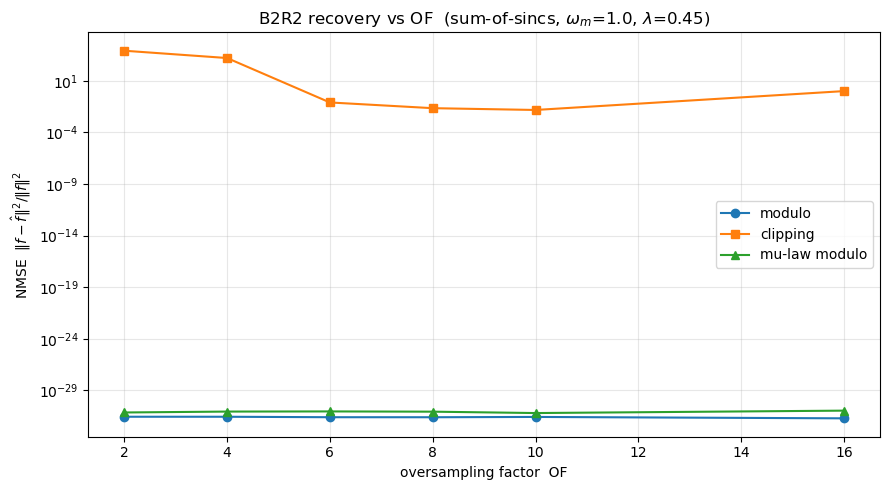

In [30]:
plot_nmse_vs_of(omega_m_show=1.0, lam_show=0.45)

Plotting the performance with a fixed `omega_m` and `lam` selected, there is a clear performance difference between clipping and the other two schemes.

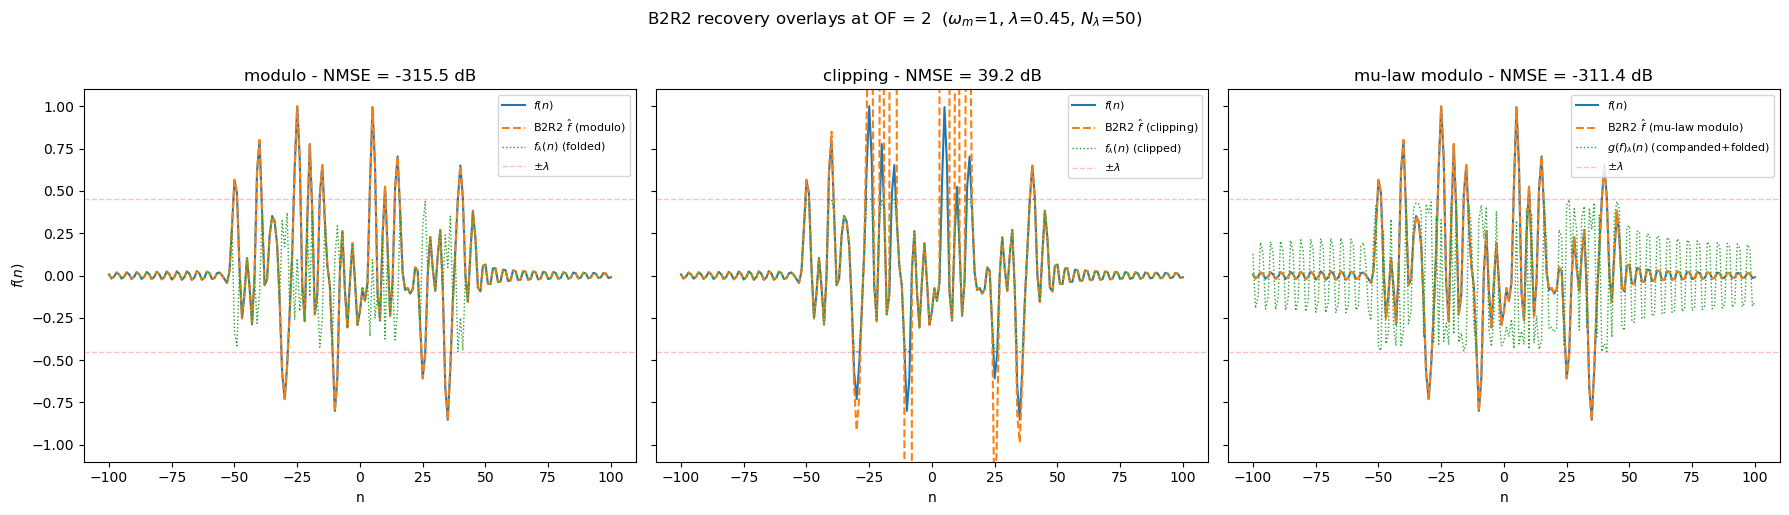

In [31]:
plot_recovery_overlays(OF_show=2, omega_m_show=1, lam_show=0.45)

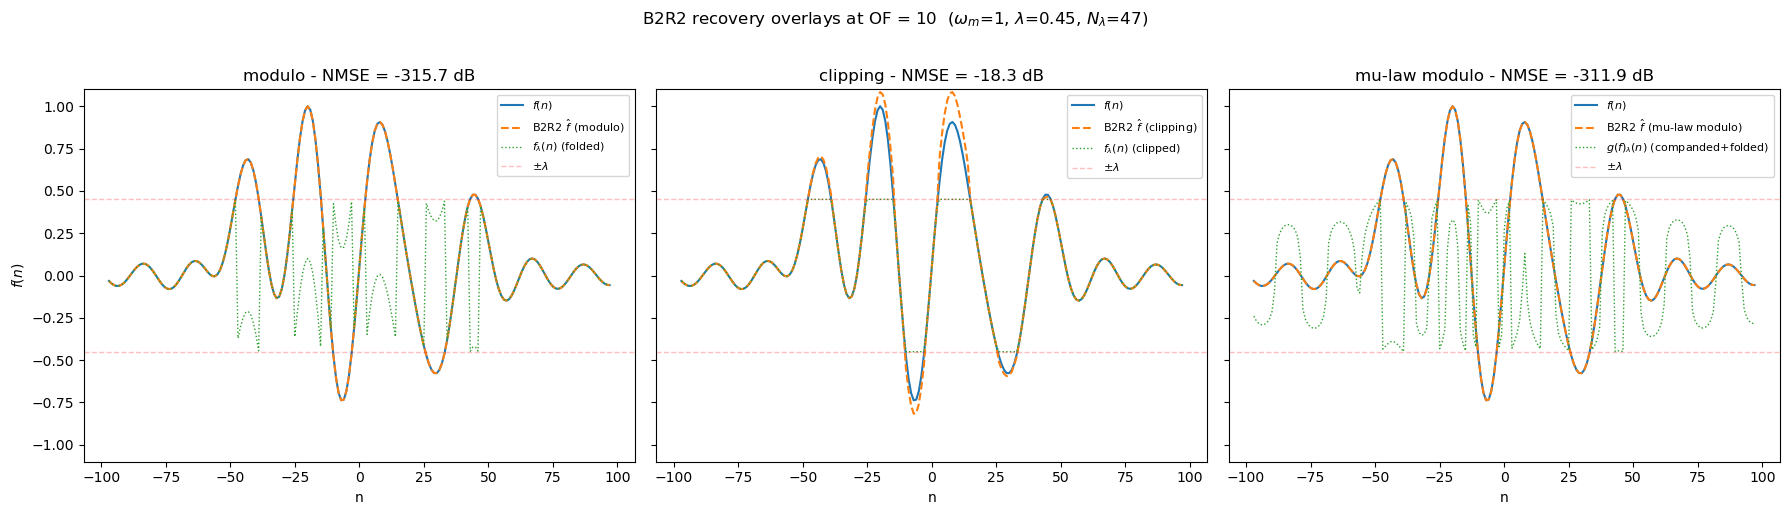

In [32]:
plot_recovery_overlays(OF_show=10, omega_m_show=1, lam_show=0.45)

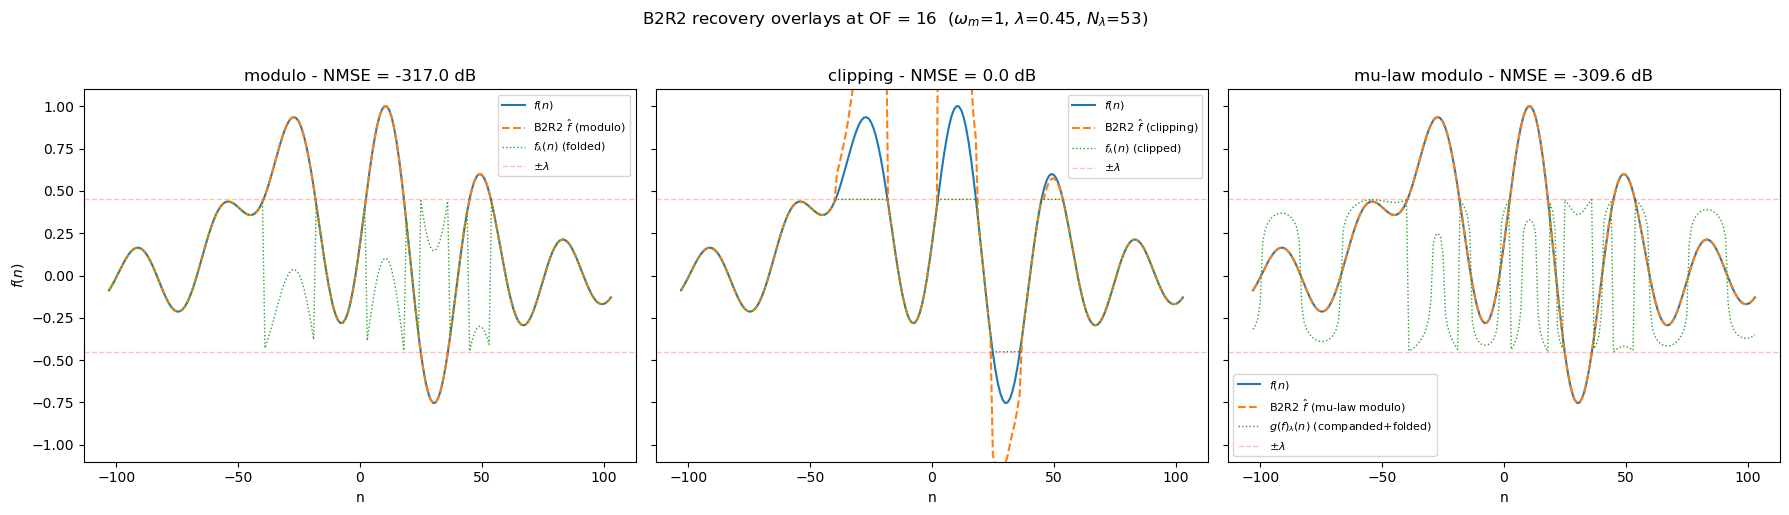

In [33]:
plot_recovery_overlays(OF_show=16, omega_m_show=1, lam_show=0.45)

The three plots above show that even for `OF=2`, both modulo and $\mu$-law modulo are perfectly able to recreate the test signal. Clipping needs at least `OF=10` to recover it acceptably. It is of note that $N_\lambda$ changes as OF changes, possibly due to the added samples within regions that are outside the DR.

## Conclusion and Future Implementation

This notebook reproduced the core result of the paper and their findings.

The direct matrix-inversion solution only works for small support windows. The $B^2R^2$ algorithm side-steps this and was able to perfectly reconstruct the modulo and the $\mu$-law modulo operators using only an oversampling factor of 2 (i.e. 2 times the Nyquist Rate). The paper also reports that a clipped signal can be recovered perfectly at an oversampling factor of 10, which was not the case in this experiment.

Future work would extend the implementation towards parts of the paper left out including, noise robustness tests and benchmarking against other unlimited sampling frameworks.